# 03 - Poisson Goals Model

Fit per-team attack and defense strengths, visualize them, draw a scoreline heatmap for a fixture, and backtest both models.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

import numpy as np
from wcpredictor.models import EloModel, PoissonModel
from wcpredictor.evaluation import backtest

In [2]:
tr = build_training_matches(load_matches(config), config)
teams = load_teams(config)
poisson = PoissonModel(config).fit(tr)
strengths = poisson.strengths_table(teams)
print('home advantage factor:', round(np.exp(poisson.home_advantage), 3))
strengths.head(15)

home advantage factor: 1.508


,team,attack,defense,net_strength,confederation,pot
0,Argentina,0.358137,0.779952,1.138089,CONMEBOL,1
1,France,0.442355,0.448632,0.890987,UEFA,1
2,Spain,0.320646,0.494635,0.815281,UEFA,1
3,Croatia,0.380191,0.381491,0.761682,UEFA,1
4,Brazil,0.349238,0.397790,0.747027,CONMEBOL,1
5,Morocco,0.363366,0.331634,0.695000,CAF,1
6,England,0.149305,0.465575,0.614880,UEFA,1
7,Germany,0.254966,0.307323,0.562289,UEFA,1
8,Portugal,0.286666,0.231604,0.518270,UEFA,1
9,Senegal,0.191207,0.260853,0.452060,CAF,2


## Attack vs defense

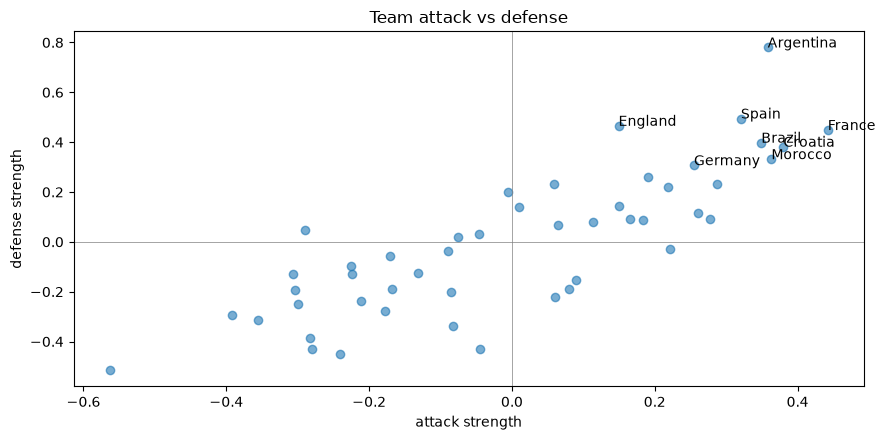

In [3]:
fig, ax = plt.subplots()
ax.scatter(strengths['attack'], strengths['defense'], alpha=0.6)
for _, r in strengths.head(8).iterrows():
    ax.annotate(r['team'], (r['attack'], r['defense']))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('attack strength'); ax.set_ylabel('defense strength')
ax.set_title('Team attack vs defense'); plt.tight_layout(); plt.show()

## Scoreline probabilities for a fixture

The annotated heatmap tints each scoreline by who it favours (blue = home win, grey = draw, red = away win) and rings the most likely score in gold.

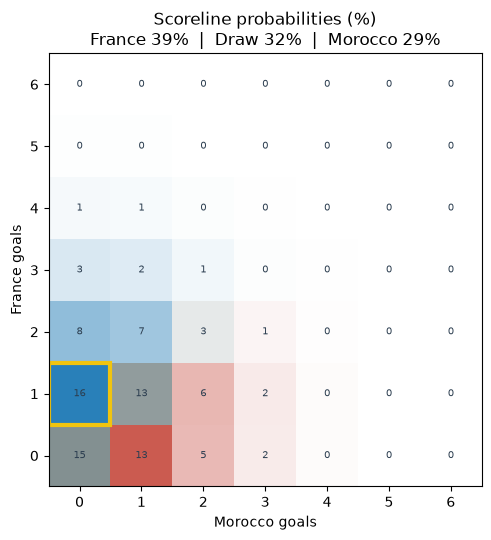

In [4]:
from wcpredictor.visualization import (plot_scoreline_heatmap,
                                       plot_match_comparison)
plot_scoreline_heatmap(poisson, 'France', 'Morocco', neutral=True)
plt.tight_layout(); plt.show()

## Match outcome: Elo vs Poisson

Compare the win/draw/loss probabilities the two models assign to the same fixture.

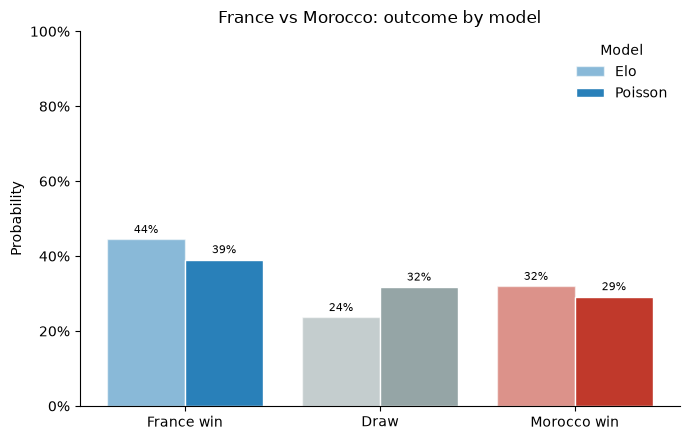

In [5]:
elo = EloModel(config).fit(tr)
home, away = 'France', 'Morocco'
preds = {'Elo': elo.predict_match(home, away, True),
         'Poisson': poisson.predict_match(home, away, True)}
plot_match_comparison(preds, home, away)
plt.tight_layout(); plt.show()

## Backtest: Elo vs Poisson

Walk-forward evaluation. Lower log-loss / RPS is better.

In [6]:
elo_res = backtest(lambda: EloModel(config), tr, config, min_train=300)
poi_res = backtest(lambda: PoissonModel(config), tr, config, min_train=300)
pd.DataFrame([dict(model='Elo', **elo_res.as_dict()),
              dict(model='Poisson', **poi_res.as_dict())])

,model,accuracy,log_loss,rps,n_matches
0,Elo,0.513725,1.030087,0.205901,1020
1,Poisson,0.502941,1.013815,0.205022,1020
